# Практика Линейной и Полиномиальной регрессии.
Для Научно-Практической конференции.

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [72]:
df = pd.read_csv('~//Downloads//Salary Data.csv')
df.drop('Job Title', axis=1, inplace=True)
df.head()

,Age,Gender,Education Level,Years of Experience,Salary
0,32.0,Male,Bachelor's,5.0,90000.0
1,28.0,Female,Master's,3.0,65000.0
2,45.0,Male,PhD,15.0,150000.0
3,36.0,Female,Bachelor's,7.0,60000.0
4,52.0,Male,Master's,20.0,200000.0


## 1. Разведочный Анализ Данных
Выполняется для:
1. Первичного знакомства с данными
2. Визуализации
3. Поиска зависимостей

### Статистики для числовых данных

In [73]:
df.describe()

,Age,Years of Experience,Salary
count,373.000000,373.000000,373.000000
mean,37.431635,10.030831,100577.345845
std,7.069073,6.557007,48240.013482
min,23.000000,0.000000,350.000000
25%,31.000000,4.000000,55000.000000
50%,36.000000,9.000000,95000.000000
75%,44.000000,15.000000,140000.000000
max,53.000000,25.000000,250000.000000


### Статистики для категориальных данных

In [74]:
df.describe(include='object')

,Gender,Education Level
count,373,373
unique,2,3
top,Male,Bachelor's
freq,194,224


### Подготовка данных

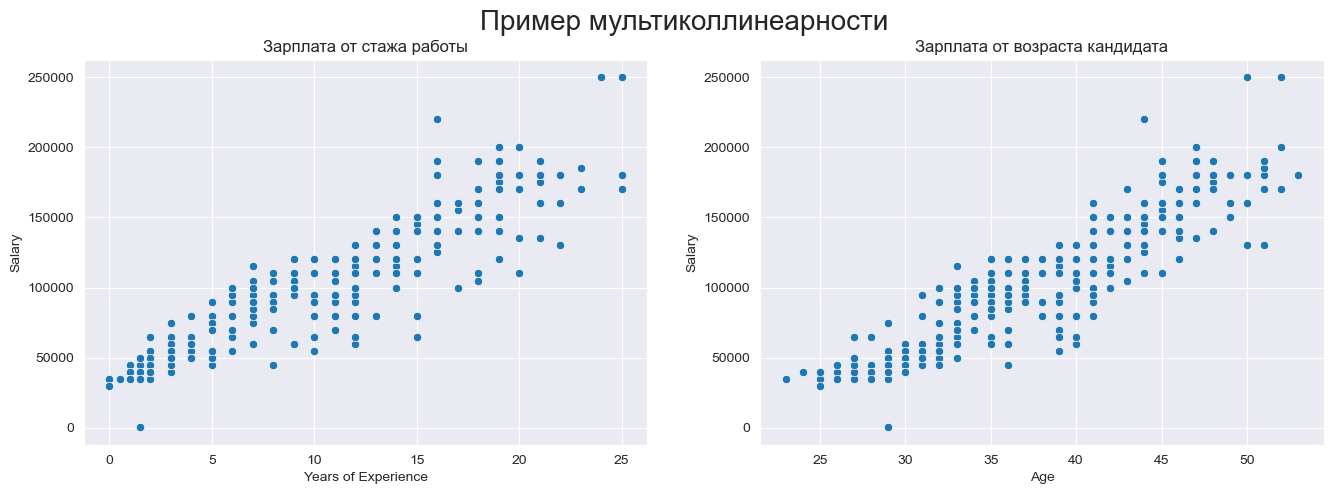

In [75]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Пример мультиколлинеарности', fontsize=20)

ax[0].set_title('Зарплата от стажа работы', fontsize=12)
sns.scatterplot(data=df, x='Years of Experience', y='Salary', ax=ax[0])

ax[1].set_title('Зарплата от возраста кандидата', fontsize=12)
sns.scatterplot(data=df, x='Age', y='Salary', ax=ax[1]);

Мультиколлинеарность негативно влияет на работу модели, поэтому оставляем только наиболее показательный признак - Стаж работы

In [76]:
df.drop('Age', axis=1, inplace=True)
df.dropna(inplace=True)
df.head()

,Gender,Education Level,Years of Experience,Salary
0,Male,Bachelor's,5.0,90000.0
1,Female,Master's,3.0,65000.0
2,Male,PhD,15.0,150000.0
3,Female,Bachelor's,7.0,60000.0
4,Male,Master's,20.0,200000.0


### Интерпретируем категориальные переменные как числовые

In [77]:
df = pd.get_dummies(df, columns=['Gender'], drop_first=True)
edu_map = {"Bachelor's": 1, "Master's": 2, "PhD": 3}
df['Education Level'] = df['Education Level'].map(edu_map)
df.head()

,Education Level,Years of Experience,Salary,Gender_Male
0,1,5.0,90000.0,True
1,2,3.0,65000.0,False
2,3,15.0,150000.0,True
3,1,7.0,60000.0,False
4,2,20.0,200000.0,True


## 2. Создание модели Машинного Обучения

In [78]:
X = df.drop('Salary', axis=1)
y = df['Salary']

### Линейная регрессия

In [79]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101)

scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)


In [80]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score

model = LinearRegression()
model.fit(scaled_X_train, y_train)
y_pred = model.predict(scaled_X_test)

print(f'Точность модели = {round(r2_score(y_test, y_pred), 3) * 100}%\n'
      f'Средняя ошибка модели = {round(root_mean_squared_error(y_test, y_pred), 2)}$')

Точность модели = 91.4%
Средняя ошибка модели = 12788.96$


Учитывая среднее значение по зарплате = 100000$, получившаяся ошибка модели довольно маленькая => модель даёт хорошие результаты.

### Полиномиальная регрессия

In [81]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

poly_scaler = StandardScaler()
scaled_X_poly_train = poly_scaler.fit_transform(X_poly_train)
scaled_X_poly_test = poly_scaler.transform(X_poly_test)


In [82]:
poly_model = LinearRegression()
poly_model.fit(scaled_X_poly_train, y_train)
y_pred_poly = poly_model.predict(scaled_X_poly_test)

print(f'Точность Полиномиальной модели = {round(root_mean_squared_error(y_test, y_pred_poly), 2)}$ или {round(r2_score(y_test, y_pred_poly), 3) * 100}%')


Точность Полиномиальной модели = 14260.63$ или 89.2%


#### Таким образом, наша модель Линейной регрессии объясняет 91% вариации зарплат, тогда как Полиномиальная модель объясняет только 89% вариации зарплат. Это позволяет компании прогнозировать бюджет на персонал с точностью ~12 000$ на сотрудника, что достаточно для стратегического планирования

### Пробуем предсказать зарплату для **_Мужчины_**, **_С дипломом магистра_** и **_Стажем = 5_**.

In [83]:
ivan = pd.DataFrame([[2, 5, 1]], columns=['Education Level', 'Years of Experience', 'Gender_Male'])

ivan_scaled = scaler.transform(ivan)
ivan_predicted_lr = model.predict(ivan_scaled)

ivan_poly = poly.transform(ivan)
ivan_poly_scaled = poly_scaler.transform(ivan_poly)
ivan_predicted_poly = poly_model.predict(ivan_poly_scaled)

print(f'Предсказание Линейной регрессии = {round(ivan_predicted_lr[0], 3)}\n'
      f'Предсказание Полиномиальной регрессии = {round(ivan_predicted_poly[0], 3)}\n')

Предсказание Линейной регрессии = 80386.973
Предсказание Полиномиальной регрессии = 79931.855



### Пробую аналитически предсказать зарплату Ивана (вручную).
Чтобы сделать это аналитически, нам нужно дестандартизировать данные (вернуть в исходную форму).
$$Salary = Intercept + (w_1 * z_{edu}) + (w_2 * z_{exp}) + (w_3 * z_{gender})$$
$$z = \frac{Значение - Среднее\ Скейлера} {Стандартное\ отклонение\ Скейлера}$$
$$Intercept_{real} = Intercept_{scaled} - \sum (\frac{w_{scaled} * \mu_i} {\sigma_i})$$

In [84]:
print(f'Среднее для Скейлера = {scaler.mean_}\n'
      f'Отклонение для Скейлера = {scaler.scale_}\n')

z_edu = (model.coef_[0] - scaler.mean_[0]) / scaler.scale_[0]
z_exp = (model.coef_[1] - scaler.mean_[1]) / scaler.scale_[1]
z_gender = (model.coef_[2] - scaler.mean_[2]) / scaler.scale_[2]

intercept_real = model.intercept_ - sum([model.coef_[i] * scaler.mean_[i] / scaler.scale_[i] for i in range(len(model.coef_))])

print('Провели дестандартизацию')
print(f'Коэффициент Образования = {z_edu}\n'
      f'Коэффициент Стажа = {z_exp}\n'
      f'Коэффициент Гендера = {z_gender}\n'
      f'Интерцепт или Пересечение с OY = {intercept_real}\n')

ivan_salary_analytics = intercept_real + z_edu * 2 + z_exp * 5 + z_gender * 1
print(f'Аналитически предсказанное значение зарплаты для Ивана = {ivan_salary_analytics}')

Среднее для Скейлера = [ 1.54626866 10.23283582  0.52537313]
Отклонение для Скейлера = [0.72283198 6.57127144 0.49935579]

Провели дестандартизацию
Коэффициент Образования = 13072.250248077486
Коэффициент Стажа = 5985.988381711185
Коэффициент Гендера = 7282.886298814617
Интерцепт или Пересечение с OY = 17016.52786829688

Аналитически предсказанное значение зарплаты для Ивана = 80373.85657182238


## 3. Визуализация результатов моделей

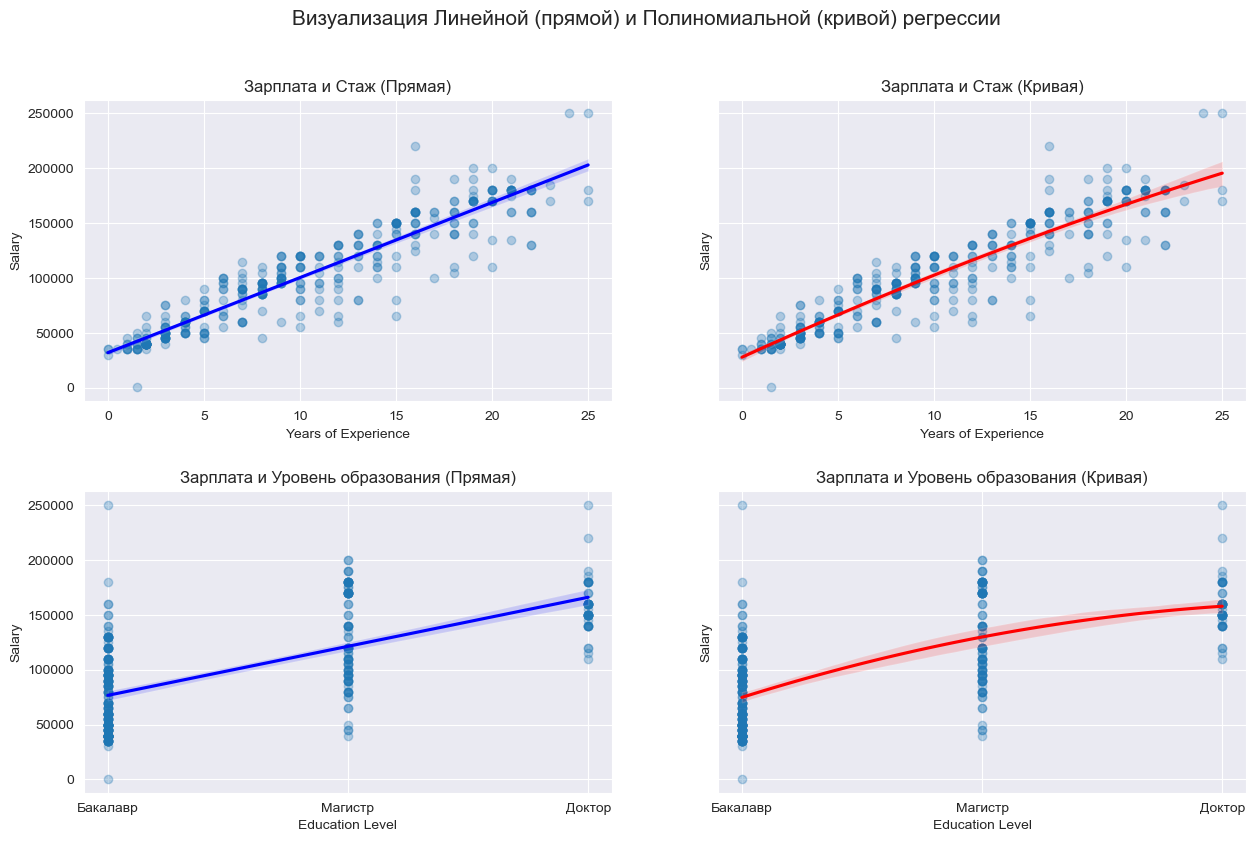

In [85]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharey=True)
fig.suptitle('Визуализация Линейной (прямой) и Полиномиальной (кривой) регрессии', fontsize=15)

# Зарплата и Год Стажа
sns.regplot(data=df, x='Years of Experience', y='Salary',
            order=1, ax=axes[0][0], line_kws={'color':'blue'}, scatter_kws={'alpha':0.3})
axes[0][0].set_title('Зарплата и Стаж (Прямая)')

sns.regplot(data=df, x='Years of Experience', y='Salary',
            order=2, ax=axes[0][1], line_kws={'color':'red'}, scatter_kws={'alpha':0.3})
axes[0][1].set_title('Зарплата и Стаж (Кривая)')

# Зарплата и Уровень образования
sns.regplot(data=df, x='Education Level', y='Salary',
            order=1, ax=axes[1][0], line_kws={'color':'blue'}, scatter_kws={'alpha':0.3})
axes[1][0].set_title('Зарплата и Уровень образования (Прямая)')
axes[1][0].set_xticks([1, 2, 3])
axes[1][0].set_xticklabels(['Бакалавр', 'Магистр', 'Доктор'])


sns.regplot(data=df, x='Education Level', y='Salary',
            order=2, ax=axes[1][1], line_kws={'color':'red'}, scatter_kws={'alpha':0.3})
axes[1][1].set_title('Зарплата и Уровень образования (Кривая)')
axes[1][1].set_xticks([1, 2, 3])
axes[1][1].set_xticklabels(['Бакалавр', 'Магистр', 'Доктор'])

fig.subplots_adjust(hspace=0.3)

In [86]:
print(f'Коэффициенты для Линейной регрессии:\n'
      f'\tslope (Уровень наклона) для Уровня образования = {model.coef_[0]}\n'
      f'\tslope (Уровень наклона) для Стажа = {model.coef_[1]}\n'
      f'\tslope (Уровень наклона) для Пола = {model.coef_[2]}\n\n'
      f'\tintercept (Пересечение с OY) = {model.intercept_}\n')

print(f'Коэффициенты для Полиномиальной регрессии:\n'
      f'\tslope (Уровень наклона) для Уровня образования = {poly_model.coef_[0]}\n'
      f'\tslope (Уровень наклона) для Стажа = {poly_model.coef_[1]}\n'
      f'\tslope (Уровень наклона) для Пола = {poly_model.coef_[2]}\n\n'
      f'\tintercept (Пересечение с OY) = {poly_model.intercept_}')

Коэффициенты для Линейной регрессии:
	slope (Уровень наклона) для Уровня образования = 9450.586850673692
	slope (Уровень наклона) для Стажа = 39345.78734598023
	slope (Уровень наклона) для Пола = 3637.2768074155924

	intercept (Пересечение с OY) = 102329.40298507463

Коэффициенты для Полиномиальной регрессии:
	slope (Уровень наклона) для Уровня образования = 31412.567712743334
	slope (Уровень наклона) для Стажа = 44240.33092159469
	slope (Уровень наклона) для Пола = 2238.8721015247215

	intercept (Пересечение с OY) = 102329.40298507464
